In [14]:
# Retail Sales Analysis

## Findings:
- Books is the top performing category by sales
- West region is most profitable, East is weakest
- Sales peaked in July 2023 and remained stable through year end

## Tools used: Python, Pandas, Matplotlib
import pandas as pd

df = pd.read_csv("retail_sales.csv")
df.columns[1:7]


Index(['Category', 'Sales', 'Quantity', 'Profit', 'Region'], dtype='object')

In [15]:
df.head()

,Date,Category,Sales,Quantity,Profit,Region
0,1/1/2023,Electronics,1149.014246,11.0,383.664245,North
1,1/1/2023,Clothing,958.520710,7.0,224.054049,East
2,1/1/2023,Home Goods,1473.763845,2.0,466.593090,South
3,1/1/2023,Sports,1230.230419,6.0,123.310460,West
4,1/1/2023,NaN?,828.585950,12.0,88.591355,East


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   object 
 1   Category  1821 non-null   object 
 2   Sales     1823 non-null   float64
 3   Quantity  1820 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1820 non-null   object 
dtypes: float64(3), object(3)
memory usage: 85.7+ KB


In [20]:
df.isnull().sum()

Date        0
Category    4
Sales       2
Quantity    5
Profit      0
Region      5
dtype: int64

In [21]:
df.dropna(inplace=True)
df.isnull().sum()  # should show all zeros now

Date        0
Category    0
Sales       0
Quantity    0
Profit      0
Region      0
dtype: int64

In [22]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()  # Date should now show datetime64

<class 'pandas.core.frame.DataFrame'>
Index: 1810 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      1810 non-null   datetime64[ns]
 1   Category  1810 non-null   object        
 2   Sales     1810 non-null   float64       
 3   Quantity  1810 non-null   float64       
 4   Profit    1810 non-null   float64       
 5   Region    1810 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 99.0+ KB


In [23]:
# 1. Which category has highest sales?
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Books          370971.872558
Electronics    364090.406288
Clothing       350981.822773
Home Goods     344634.290152
Sports         341349.880348
Null             1106.847949
NaN?              828.585950
Nan               823.190573
Name: Sales, dtype: float64

In [24]:
# 2. Which region is most profitable?
df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

Region
West     122329.449142
South    117569.442029
North    110775.161869
East      98360.225010
Nan         545.617726
Name: Profit, dtype: float64

In [25]:

df['Month'] = df['Date'].dt.to_period('M')
df.groupby('Month')['Sales'].sum()


Month
2023-01    134435.595627
2023-02    132215.411776
2023-03    145321.200626
2023-04    138160.991209
2023-05    150774.977103
2023-06    152605.749860
2023-07    162111.115687
2023-08    148020.452251
2023-09    153094.700793
2023-10    151272.280840
2023-11    146795.613628
2023-12    159978.807192
Freq: M, Name: Sales, dtype: float64

In [26]:
df = df[~df['Category'].isin(['Null', 'NaN?', 'Nan'])]
df = df[~df['Region'].isin(['Nan'])]

# verify
df['Category'].unique()
df['Region'].unique()

array(['North', 'East', 'South', 'West'], dtype=object)

In [27]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Books          370971.872558
Electronics    362373.695501
Clothing       350981.822773
Home Goods     344634.290152
Sports         341349.880348
Name: Sales, dtype: float64

In [28]:
df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

Region
West     121947.664564
South    117316.008728
North    110775.161869
East      98271.633655
Name: Profit, dtype: float64

In [29]:
df.groupby('Month')['Sales'].sum()

Month
2023-01    129960.260368
2023-02    132215.411776
2023-03    145321.200626
2023-04    138160.991209
2023-05    150774.977103
2023-06    152605.749860
2023-07    162111.115687
2023-08    148020.452251
2023-09    153094.700793
2023-10    151272.280840
2023-11    146795.613628
2023-12    159978.807192
Freq: M, Name: Sales, dtype: float64

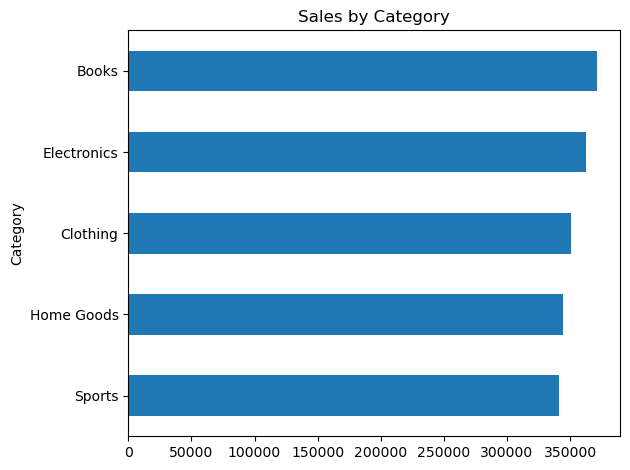

In [30]:
import matplotlib.pyplot as plt

# Chart 1 - Sales by Category
df.groupby('Category')['Sales'].sum().sort_values().plot(kind='barh')
plt.title('Sales by Category')
plt.tight_layout()
plt.show()

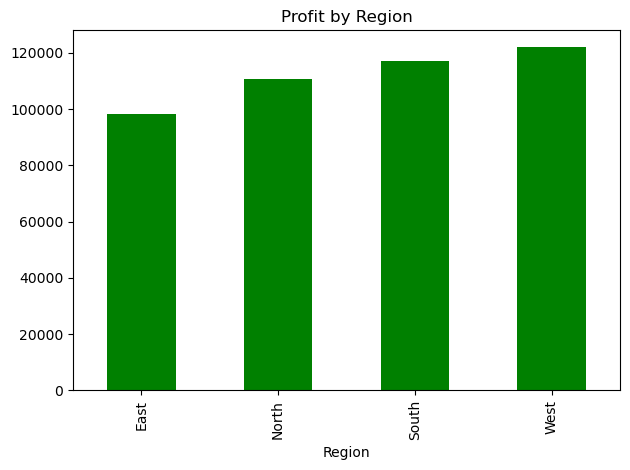

In [31]:
# Chart 2 - Profit by Region
df.groupby('Region')['Profit'].sum().sort_values().plot(kind='bar', color='green')
plt.title('Profit by Region')
plt.tight_layout()
plt.show()

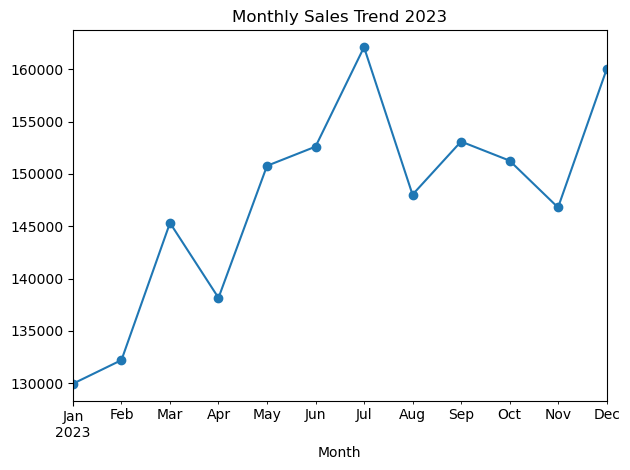

In [32]:
# Chart 3 - Monthly Sales Trend
df.groupby('Month')['Sales'].sum().plot(kind='line', marker='o')
plt.title('Monthly Sales Trend 2023')
plt.tight_layout()
plt.show()